# SciPy: Hypothesis Testing

## 1. Overview

### 1.1. Basic concepts
[Hypothesis testing](https://en.wikipedia.org/wiki/Statistical_hypothesis_testing) is a method of statistical inference that tests the validity of a claim about the population, using sample data. It makes use of the following concepts.

#### Hypotheses
- The [null hypothesis] (denoted $H_0$): a common view whose validity needs to be tested.
- The [alternative hypothesis] (denoted $H_1$): what will be believed if $H_0$ is rejected.

[null hypothesis]: https://en.wikipedia.org/wiki/Null_hypothesis
[alternative hypothesis]: https://en.wikipedia.org/wiki/Alternative_hypothesis

#### Significance level
[Significance level] (denoted $\alpha$) is a pre-selected number ranges from $0$ to $1$, indicates the probability of rejecting the null hypothesis. Common values of $\alpha$ is $0.05$ and $0.01$. A related concept to significance level is [confidence level] (denoted $\gamma=1-\alpha$). Each significance level corresponds to a critical value ($c$).

[Significance level]: https://en.wikipedia.org/wiki/Statistical_significance
[confidence level]: https://en.wikipedia.org/wiki/Confidence_interval

#### Test statistic
Being one of the most important factors, [test statistic](https://en.wikipedia.org/wiki/Test_statistic) (denoted $T$) is the transformed data that follows a theoretical distribution. Since the probability distribution function is known, it allows calculating the probability value, telling which hypothesis is more likely to happen. Each test statistic is represented by a fraction where:
- The numerator is the power of signal
- The denominator is the power of noise

[test statistic]: https://en.wikipedia.org/wiki/Test_statistic

#### p-value
[p-value] is the probability of making [type I error] - rejecting $H_0$ when it's true. It represents the probability of $H_0$ being true, and when this probability is less than $\alpha$, $H_0$ should be rejected. The smaller the p-value is, the stronger the evidence that $H_0$ should be rejected.
- A p-value less than $0.05$ indicates the difference is significant, meaning there is a probability of less than $5\%$ that the null hypothesis is correct. Therefore, $H_0$ is rejected and $H_1$ is accepted.
- A p-value higher than $0.05$ indicates the difference is not significant. In this case, $H_1$ is rejected but $H_0$ is failed to be rejected.

[p-value]: https://en.wikipedia.org/wiki/P-value
[type I error]: https://en.wikipedia.org/wiki/Type_I_and_type_II_errors

In [3]:
import sys; sys.path.append('..')
from mlkit import np, stats, plt, sns

In [0]:
mu, std = 0, 1
dist = stats.norm(mu, std)

In [0]:
# compute critical value (c) given a significance level (alpha)
# 2-tailed test
alpha = 0.05
crit = dist.isf(alpha/2)
crit

In [0]:
# compute p-value (p) given a test statistic (t)
# 2-tailed test
test = 1.96
test = np.abs(test)
pval = dist.cdf(-test) + dist.sf(test)
pval

#### Descriptive statistics
For populations:
- $\mu$: population mean
- $\sigma$: population standard deviation
- $\sigma^2$: population variance
- $p$: proportion of successes in population

For samples:
- $n$: sample size
- $\hat\mu$ or $\bar x$: sample mean
- $\hat\sigma$ or $\text{SD}$: sample standard deviation
- $\hat\sigma^2$ or $s^2$: sample variance
- $\hat p$: proportion of successes in sample
- $\text{SE}$: standard error of mean

### 1.2. Hypothesis testing summary
Type  |Usage
:----------|:--------------
Z-test|Comparing population means or proportions
F-test|Comparing the variances of 2 populations
t-test|Comparing the means of 1 or 2 populations
Chi-squared test|Testing of qualitative variables replationship
ANOVA|Comparing the means of 3 population or more
KS test|Testing of distribution

## 2. Core tests

### 2.1. Proportion Z-test

#### Z-test
[Z-test] is any test that the test statistic follows a normal distribution. The very most basic use of Z-test is to compare a sample mean to an arbitrary constant $c$ when the population variance is known. The test statistic for this test is calculated as:

$$T = \frac{\hat{\mu}-c}{\text{SE}}\quad\text{for } \text{SE} = \sqrt{\frac{\sigma^2}{n}}$$

This test can also be extended to the case that involves two samples:

$$T=\frac{(\hat{\mu}_1-\hat{\mu}_2)-c}{\text{SE}}
\quad\text{for }\text{SE}=\sqrt{\frac{\sigma_1^2}{n_1}+\frac{\sigma_2^2}{n_2}}$$

[Z-test]: https://en.wikipedia.org/wiki/Z-test

:::{note}

In real-world scenarios, z-test is rarely used as the population variance is usually unknown. However, it serves as a strong foundation for other statistical tests.

:::

#### Proportion test
When our data is binary, Z-test can be used to compare the proportion of successes in one or two populations. The test statistic for one-sample proportion Z-test is calculated as:

$$T = \frac{\hat{p}-c}{\text{SE}}\sim\mathcal{N}(0,1)
\qquad\text{for }\text{SE}=\sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

And the test statistic for two-sample proportion Z-test is:

$$T = \frac{(\hat{p}_1-\hat{p}_2)-c}{\text{SE}}\sim\mathcal{N}(0,1)
\qquad\text{for }\text{SE}=\sqrt{\frac{\hat{p}_1(1-\hat{p}_1)}{n_1}+\frac{\hat{p}_2(1-\hat{p}_2)}{n_2}}$$

:::{admonition} Case
:class: tip

In a large consignment of food packets, a random sample of $n=100$ packets revealed that 5 packets were leaking. Can we conclude that the population contains at least $A=10\%$ of leaked packets at $\alpha=0.05$?

The hypotheses:
- $H_0: p\geq0.1$
- $H_1: p<0.1$

This is a left-tailed test, $H_0$ will be rejected if $T<-z_{0.05}=-1.64$. For $T=-2.294$, the corresponding p-value is $0.011$ ($<0.05$).

:::

In [1]:
import sys; sys.path.append('..')
from mlkit import np, stats, plt
from hypo import ProportionTest, MeanTest, VarianceTest

In [2]:
test = ProportionTest(prop=5/100, size=100, const=0.1, alternative='<', alpha=0.05)
test.conduct(print_result=True)

Alternative Hypothesis (H1): p < 0.1
p-value = 0.0109 < 0.05 --> REJECT H0


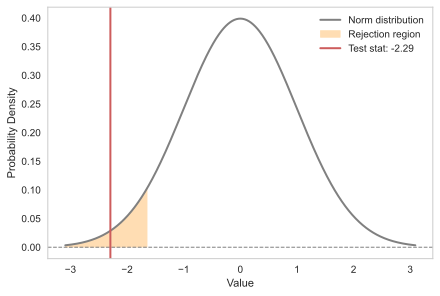

In [3]:
test.plot()

### 2.2. Mean t-test
Since population variances are rarely known in real-world scenarios, the [t-test] is the standard choice for mean estimation. The one-sample test statistic follows the standard $t$ formula:

$$T = \frac{\hat{\mu}-c}{\hat\sigma/\sqrt{n}} \sim t(n-1)$$

In the two-sample case, the formulation of the test statistic adjusts based on the assumption of homoscedasticity (equal variances). While the underlying logic remains consistent with the one-sample case.

:::{admonition} Case
:class: tip

With the confidence level of $\alpha=0.05$, the mean of income is $13500$ or not?

The hypotheses:
- $H_0: \mu=13500$
- $H_1: \mu\neq13500$

:::

In [4]:
import sys; sys.path.append('..')
from mlkit import np, pd, stats, plt
from hypo import ProportionTest, MeanTest, VarianceTest

In [5]:
columns = ['age', 'gender', 'income', 'age_group', 'degree', 'area', 'id', 'job']
df = pd.read_csv('../data/hypothesis.csv', usecols=columns)

In [6]:
test = MeanTest.from_data(df['income'], const=13500, alternative='!=', alpha=0.05)
test.conduct()

Alternative Hypothesis (H1): mean != 13500
p-value = 0.2609 > 0.05 --> ACCEPT H0


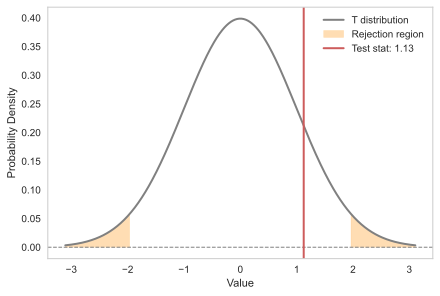

In [7]:
test.plot()

### 2.3.  Variance test
We use [$\chi^2$-test] for one-sample variance:

$$T=\frac{(n-1)\hat\sigma^2}{c} \sim \chi^2(n-1)$$

And [F-test] to compare the variances of two populations:

$$T = \frac{1}{c}\frac{\hat{\sigma}_1^2}{\hat{\sigma}_2^2}\sim F(n_1-1,n_2-1)$$

[$\chi^2$-test]: https://en.wikipedia.org/wiki/Chi-squared_test
[F-test]: https://en.wikipedia.org/wiki/F-test

:::{admonition} Case
:class: tip
With the significance level $\alpha=0.05$, compare the population variances of income of male and female. The hypotheses:
- $H_0: \sigma^2_1 \leq 5\sigma^2_2$
- $H_1: \sigma^2_1 > 5\sigma^2_2$

:::

In [8]:
import sys; sys.path.append('..')
from mlkit import np, pd, stats, plt
from hypo import ProportionTest, MeanTest, VarianceTest

In [9]:
columns = ['age', 'gender', 'income', 'age_group', 'degree', 'area', 'id', 'job']
df = pd.read_csv('../data/hypothesis.csv', usecols=columns)

x1 = df.query("gender == 'male'")['income']
x2 = df.query("gender == 'female'")['income']

In [10]:
test = VarianceTest.from_data(x1, x2, const=5, alternative='>', alpha=0.05)
test.conduct()

Alternative Hypothesis (H1): var1 / var2 > 5
p-value = 0.0303 < 0.05 --> REJECT H0


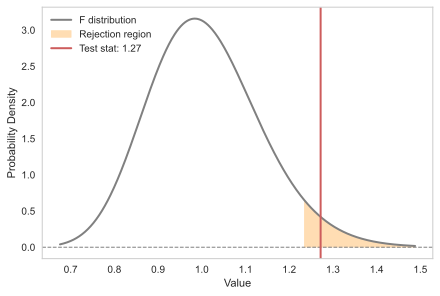

In [11]:
test.plot()

## 3. Other tests

### 3.1. Chi-squared test
Beside variance test, [chi-squared test] can also be used for:
- *Independence*: test whether two categorical variables are correlated. This is the most common use of chi-squared test.
- *Goodness-of-fit*: check if a count frequency fits a specific distribution. In practice, other tests like KS test, which require no binning, are preferred.
- *Proportion*: compare proportions from multiple groups. In practice, z-test is preferred for one or two samples.

For either purpose, the test statistic has a general form:

$$T=\sum_i\frac{(O_i-E_i)^2}{E_i}\sim\chi^2(k-1)$$

where $O_i$ is the observed frequency, $E_i$ is the expected frequency, and $k$ is the number of categories.

[chi-squared test]: https://en.wikipedia.org/wiki/Chi-squared_test

In [0]:
import sys; sys.path.append('..')
from mlkit import np, pd, stats, pg

In [0]:
columns = ['age', 'gender', 'income', 'age_group', 'degree', 'area', 'id', 'job']
df = pd.read_csv('../data/hypothesis.csv', usecols=columns)
df.head()

#### Dependence test

:::{admonition} Case
:class: tip
Is there a relationship between `age_group` and `degree`?

The hypotheses:
- $H_0:$ The two variables are independent
- $H_1:$ The two variables are dependent

`age_group` and `degree` are said to be strongly related if p-value $<0.05$.
:::

In [0]:
table = pd.crosstab(df.age_group,df.degree)

In [0]:
chi, pvalue, dof, _ = stats.chi2_contingency(table)
print("chi stats:", chi)
print('p-value:', pvalue)

In [0]:
expected, observed, summary = pg.chi2_independence(data=df, x='age_group', y='degree')

In [0]:
expected

In [0]:
summary

#### Proportion test
In R, Yate's correction chi-squared test is used for the `prop.test()` function. A Pearson's chi-squared is upward bias for 2x2 contingency table - an upwards bias tends to make results larger than they should be so Yate's correction is a regularization term in the formula of chi-squared statistic. However, Yate correction shouldn't be used because the correction is too strict for making the decision on data. In that case, `stats.chisquare()` function can be used for proportion chi-squared.

:::{admonition} Case
:class: tip
The number of officers is equal to the number of salespersons and is 5 times greater than the number of managers, true or false?
- $H_0: p_1=1/11, p_2=p_3=5/11$
- $H_1$: There is at least one incorrect equation.
:::

In [0]:
df_chi = df.groupby('job').count()[['id']].reset_index()

df_chi['obs'] = df_chi.id/len(df)
df_chi['exp'] = [1/11,5/11,5/11]

In [0]:
df_chi

In [0]:
stats.chisquare(df_chi.obs,df_chi.exp)

### 3.2. One-way ANOVA
[ANOVA] (Analysis of Variance) is a technique involving a collection of statistical tests analyzing the difference of the means of two or more groups. The means is calculated from a quantitative variable; the groups are determined using qualitative variables.

:::{image} ../image/chap_02/anova_flowchart.svg
:height: 300px
:align: center
:::

[ANOVA]: https://en.wikipedia.org/wiki/Analysis_of_variance

Usage: Compare multiple population means when there is a categorical variable containing at least three categories.

Assumptions:
- Populations are normally distributed
- Samples are random
- Homogeneity of variances

The work flow:
1. Test the homogeneity of variances, using one of the following tests:
    - [Bartlett's test], implemented via [`stats.bartlett()`]
    - [Levene's test], implemented via [`stats.levene()`]
    - Fligner-Killeen test, implemented via [`stats.fligner()`]
2. Test the equality of population means:
    - If the variances are equal, use [`stats.f_oneway()`] or [`pg.anova()`]
    - If the variances are not equal, use [`pg.welch_anova()`]
3. Post-hoc test to compare pairwise population means:
    - If the variances are equal, use [Tukey's HSD test], implemented via [`pg.pairwise_tukey()`]
    - If the variances are not equal, use Games-Howell test, implemented via [`pg.pairwise_gameshowell()`]
    
[Bartlett's test]: https://en.wikipedia.org/wiki/Bartlett%27s_test
[Levene's test]: https://en.wikipedia.org/wiki/Levene%27s_test
[Tukey's HSD test]: https://en.wikipedia.org/wiki/Tukey%27s_range_test

[`stats.bartlett()`]: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bartlett.html
[`stats.levene()`]: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.levene.html
[`stats.fligner()`]: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.fligner.html
[`stats.f_oneway()`]: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html
[`pg.anova()`]: https://pingouin-stats.org/build/html/generated/pingouin.anova.html
[`pg.welch_anova()`]: https://pingouin-stats.org/build/html/generated/pingouin.welch_anova.html
[`pg.pairwise_tukey()`]: https://pingouin-stats.org/build/html/generated/pingouin.pairwise_tukey.html
[`pg.pairwise_gameshowell()`]: https://pingouin-stats.org/build/html/generated/pingouin.pairwise_gameshowell.html

In [ ]:
import sys; sys.path.append('..')
from mlkit import np, pd, stats, pg

In [0]:
columns = ['age', 'gender', 'income', 'age_group', 'degree', 'area', 'id', 'job']
df = pd.read_csv('../data/hypothesis.csv', usecols=columns)
df.head()

:::{admonition} Case
:class: tip
Is there a difference in average income between 3 areas (Central, Southern and Northern)? If there is, which group differs from the others?
:::

*Step 1*: Check the equality of population variances. If p-value $<0.05$, then reject $H_0$. The hypotheses:
- $H_0: \sigma_1^2 = \sigma_2^2 = \dots = \sigma_k^2$
- $H_1$: Exist at least one pair $\sigma_i^2 \neq \sigma_j^2 $ where $i \neq j$

In [0]:
central = df[df['area'] =='central']['income']
northern = df[df['area'] =='northern']['income']
southern = df[df['area'] =='southern']['income']

In [0]:
stats.bartlett(central, northern, southern)

*Step 2*: Test whether the population means are equal or not. If p-value $<0.05$, then reject $H_0$. The hypotheses:
- $H_0$: $\mu_1 = \mu_2 = \dots = \mu_k$
- $H_1$: There is at least one pair $\mu_i \neq \mu_j $ where $i \neq j$

In [0]:
stats.f_oneway(central, northern, southern)

In [0]:
pg.anova(data=df, dv='income', between='area')

In [0]:
pg.welch_anova(data=df, dv='income', between='area')

*Step 3*: Post-hoc test to compare pairwise means. Any pair having p-value $<0.05$ can be considered significantly different in mean. 

In [0]:
pg.pairwise_tukey(data=df, dv='income', between='area')

In [0]:
pg.pairwise_gameshowell(data=df, dv='income', between='area')

### 3.3. Distribution fit
The [Kolmogorov-Smirnov test] (KS test) is used to test whether a random variable follows a specific distribution or not. The test statistic is calculated as the difference between the empirical CDF of the observed variable and the CDF of the reference distribution. In SciPy, the [`stats.ks()`] function performs Kolmogorov-Smirnov test, which supports any [SciPy distribution].

[Kolmogorov-Smirnov test]: https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test
[SciPy distribution]: https://docs.scipy.org/doc/scipy/reference/stats.html#probability-distributions
[`stats.ks()`]: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kstest.html

In [0]:
import sys; sys.path.append('..')
from mlkit import np, pd, stats

In [0]:
columns = ['age', 'gender', 'income', 'age_group', 'degree', 'area', 'id', 'job']
df = pd.read_csv('../data/hypothesis.csv', usecols=columns)
df.head()

In [0]:
stats.kstest(df.age, cdf = 'norm', args=(24, 0.05))

## Resources
- ethanweed.github.io - [Learning Statistics with Python](https://ethanweed.github.io/pythonbook/landingpage.html)